# ИТОГ EDA

- После очистки в датасете осталось 290585 строк.
- Тест проходил с 2 по 24 января 2025 года, то есть примерно 22 дня.
- Группы получились почти одинаковыми по размеру: около 145к пользователей в каждой. Это супер, так как разделение пользователей на контрольную и экспериментальную группы выглядит корректным.
- **Средняя конверсия в регистрацию составила примерно 12%.**
- В контрольной группе конверсия была около 12.04%, а в экспериментальной — около 11.89%. То есть НАВЕРНОЕ новый лендинг показывает результат чуть хуже старого, но пока **нельзя** делать окончательный вывод без стат проверки.
- Данные скорее всего синтетические — аномально равномерное распределение по часам


---

### ПРЕДВАРИТЕЛЬНЫЙ ВЫВОД ПО РЕЗУЛЬТАТАМ Z-ТЕСТА

**p-value=0.1897 >>> а=0.05**

Значит мы не отвергаем H0.
Статистически значимой разницы между группами нет.

Новый лендинг **не улучшил конверсию.**

## **Новый лендинг внедрять не стоит.**
---

здесь начинается работа..


## Начнем с EDA
Во-первых, стоит разобраться с чем мы вообще имеем дело и понять как с этим работать.

#### Датасет и задача (контекст)
Мы имеем результаты проведенного A/B-теста в образовательной компании. 5 колонок: user_id, timestamp, group, landing_page, converted. И на основе данного датасета мы должны понять: влияет ли новый лендинг по сравнению со старым на конверсию в целевое действие (то есть зарегистрировался ли на курс)?

#### Что уже пугает?
Пощупав чистые данные я уже вижу, что, у нас просочились в treatment - `old page`, а в control - `new_page`. Важно будет отсечь таких людей.

<img src="images/image_con_new.png" width="300">

<img src="images/image_tr_old.png" width="300">

Если пользователь из контрольной выборки видел новый лендинг -- мы не уверены как это произошло, лучше выкидывать такие кадры. Чтобы анализ был более правильным - я снесу такие строки с несоответствиями

## Начнем с базового EDA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('data_ab.csv')
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


глянем на то, какие ячейки какие типы данных принимают сейчас

In [34]:
df.dtypes

,0
user_id,int64
timestamp,object
group,object
landing_page,object
converted,int64


ага. таймстампы надо перевести в dt, а converted в boolean

In [35]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['converted'] = df['converted'].astype(bool)
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,False
1,804228,2025-01-12 08:01:45.159739,control,old_page,False
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,False
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,False
4,864975,2025-01-21 01:52:26.210827,control,old_page,True
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,False
294474,945152,2025-01-12 00:51:57.078372,control,old_page,False
294475,734608,2025-01-22 11:45:03.439544,control,old_page,False
294476,697314,2025-01-15 01:20:28.957438,control,old_page,False


In [36]:
df.dtypes

,0
user_id,int64
timestamp,datetime64[ns]
group,object
landing_page,object
converted,bool


глянем на размер датасета

In [37]:
f"Размер датасета: {df.shape[0]}"


'Размер датасета: 294478'

Теперь глянем на пропуски и другие проблемы в датасете

In [38]:
df.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


пропусков в датасете нет. это в принципе ожидаемо для таких автологированных слишком "ровных датасетов"

но все же глянем еще и дубликаты

In [39]:
f'полных дубликатов: {df.duplicated().sum()}'

'полных дубликатов: 0'

In [40]:
f'Дубликатов user_id: {df["user_id"].duplicated().sum()}'

'Дубликатов user_id: 3894'

In [41]:
print('сколкьо встречается каждого user_id:')
df.groupby('user_id').size().value_counts().sort_index()

сколкьо встречается каждого user_id:


,count
1,286690
2,3894


полностью дублирующихся строк нет, все строки уникальны по совокупности.
Но! все же есть 3894 пользователя, которые встречаются дважды (больше двух раз — никого)

Это может означать то, что часть пользователей посетила лендинг повторно. `может это те, кто несоответвовали своей выборке? `

#### вернемся к проблеме с несоответствующими пользователями
построим кросс-табуляцию чтобы посмотреть пересечения

In [42]:
pd.crosstab(df['group'], df['landing_page'], margins=True)

landing_page,new_page,old_page,All
group,,,
control,1928,145274,147202
treatment,145311,1965,147276
All,147239,147239,294478


In [43]:
1928+1965
# ну я думаю тут уже становится понятно в чем дело, но давайте перепроверим,
# что это рил те пользователи

3893

построим wrong_control и wrong_treatment чтобы взглянуть на них поближе и убедиться что это именно дубликаты

In [44]:
wrong_control = (df['group'] == 'control') & (df['landing_page'] == 'new_page')
wrong_treatment = (df['group'] == 'treatment') & (df['landing_page'] == 'old_page')

mismatch = df[wrong_control | wrong_treatment]
mismatch

,user_id,timestamp,group,landing_page,converted
22,767017,2025-01-12 22:58:14.991443,control,new_page,False
240,733976,2025-01-11 15:11:16.407599,control,new_page,False
308,857184,2025-01-20 07:34:59.832626,treatment,old_page,False
327,686623,2025-01-09 14:26:40.734775,treatment,old_page,False
357,856078,2025-01-12 12:29:30.354835,treatment,old_page,False
...,...,...,...,...,...
294014,813406,2025-01-09 06:25:33.223301,treatment,old_page,False
294200,928506,2025-01-13 21:32:10.491309,control,new_page,False
294252,892498,2025-01-22 01:11:10.463211,treatment,old_page,False
294253,886135,2025-01-06 12:49:20.509403,control,new_page,False


In [45]:
df[df['user_id'].isin(mismatch['user_id'])].sort_values(['user_id', 'timestamp'])

,user_id,timestamp,group,landing_page,converted
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,True
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,False
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,False
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,False
183371,630137,2025-01-20 02:08:49.893878,control,old_page,False
...,...,...,...,...,...
99479,945703,2025-01-18 06:39:31.294688,control,old_page,False
40370,945797,2025-01-11 03:04:49.433736,control,new_page,True
186960,945797,2025-01-13 17:23:21.750962,control,old_page,False
165143,945971,2025-01-16 10:09:18.383183,control,old_page,False


Супер! мы поняли, что не так с этими 3893 пользователями: они увидели не свою версию лендинга. и судя по всему, когда человек заходит второй раз, попадалит в другой лэндинг. ЧТО СОВСЕМ НЕ ОК, так как это не соответствует качественному а/б тесту. **дропаем такие строки!**

In [46]:
print(df.count())
df_cleaned = df[~(wrong_control | wrong_treatment)].reset_index(drop=True)
df_cleaned.count()

user_id         294478
timestamp       294478
group           294478
landing_page    294478
converted       294478
dtype: int64


,0
user_id,290585
timestamp,290585
group,290585
landing_page,290585
converted,290585


### Анализ визитов

In [47]:
raw_df = pd.read_csv('data_ab.csv')
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])
dup = raw_df[raw_df['user_id'].duplicated(keep=False)].copy()
dup = dup.sort_values(['user_id', 'timestamp'])
dup['visit_num'] = dup.groupby('user_id').cumcount() + 1 #скока раз встретился юзер

In [48]:
d1 = dup[dup['visit_num'] == 1]

print('Несоответствий на первом визите: ')
print(len(d1[((d1['group']=='control') & (d1['landing_page']=='new_page')) | ((d1['group']=='treatment') & (d1['landing_page']=='old_page'))]))

print('конверсия на первом визите: ')
print(d1['converted'].mean())


Несоответствий на первом визите: 
1949
конверсия на первом визите: 
0.1325115562403698


In [49]:
d2 = dup[dup['visit_num'] == 2]

print('Несоответствий на втором визите: ')
print(len(d2[((d2['group']=='control') & (d2['landing_page']=='new_page')) | ((d2['group']=='treatment') & (d2['landing_page']=='old_page'))]))

print('конверсия на втором визите: ')
print(d2['converted'].mean())

Несоответствий на втором визите: 
1944
конверсия на втором визите: 
0.12223934257832562


ну а теперь посмотрим как менялись группа и лендинг между визитами

In [50]:
merged = d1[['user_id','group','landing_page']].merge(d2[['user_id','group','landing_page']], on='user_id', suffixes=('_v1','_v2'))

print(f"Сменили группу между визитами:   {(merged['group_v1'] != merged['group_v2']).sum()}")
print(f"Сменили лендинг между визитами:  {(merged['landing_page_v1'] != merged['landing_page_v2']).sum()}")

Сменили группу между визитами:   1895
Сменили лендинг между визитами:  1998


Ну и смена лендинга:

In [51]:
print(merged.groupby(['landing_page_v1','landing_page_v2']).size())

landing_page_v1  landing_page_v2
new_page         new_page            922
                 old_page            972
old_page         new_page           1026
                 old_page            974
dtype: int64


глянем как выглядят конкретные пользователи

In [52]:
dup[dup['user_id'].isin(dup['user_id'].unique()[:4])][['user_id','visit_num','group','landing_page','converted']]

,user_id,visit_num,group,landing_page,converted
213114,630052,1,treatment,old_page,1
230259,630052,2,treatment,new_page,0
22513,630126,1,treatment,old_page,0
251762,630126,2,treatment,new_page,0
183371,630137,1,control,old_page,0
11792,630137,2,control,new_page,0
207211,630320,1,control,old_page,0
255753,630320,2,treatment,old_page,0


**Вывод:** Несоответствия распределены поровну между первым и вторым визитом — система рандомизировала пользователя заново при каждом посещении, не запоминая предыдущее назначение. 1 895 пользователей при повторном визите даже сменили группу. Это нарушает АЙДЕНТИКУ проведения A/B теста, так что такие строки ————— **сносим**


### MDE

Проверим корректность проведения тестирования. Об этом методе почитали тут:
https://webask.io/glossary/mde

In [53]:
from scipy.stats import norm

In [54]:
df_clean = df_cleaned.drop_duplicates(subset = "user_id")
df_clean['date'] = df_clean['timestamp'].dt.date
cr_control = df_clean[df_clean['group'] == 'control']['converted'].mean()
cr_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].mean()
diff = cr_treatment - cr_control

/tmp/ipykernel_5994/297480322.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = df_clean['timestamp'].dt.date


In [55]:
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

# считаем количество пользователей
n_control = len(control)
n_treatment = len(treatment)

In [56]:
p_bar = (cr_control + cr_treatment) / 2
n = min(n_control, n_treatment)
mde = (norm.ppf(0.975) + norm.ppf(0.80)) * np.sqrt(2 * p_bar * (1 - p_bar) / n)

In [57]:
print(f"MDE: {mde*100} п.п.")
print(f"Наблюдаемая разница: {abs(cr_treatment - cr_control)*100} п.п.")

MDE: 0.3373075622078167 п.п.
Наблюдаемая разница: 0.15782389853555567 п.п.


In [58]:
print(abs(cr_treatment - cr_control))

0.0015782389853555567


**Вывод:** MDE при нашей выборке — 0.34 п.п. Наблюдаемая разница между группами — 0.16 п.п. — ниже этого порога.
Это значит: даже если эффект и есть, он настолько мал, что наш тест даже не может его прочувствовать.
**С точки зрения бизнеса — улучшение в 0.16 п.п. не представляет практической ценности и не оправдывает внедрение нового лендинга.**

###Снова к очистке

В связи с тем, что изначально было 3894 дубликата, а, выявив несоотвествие показа по контрольной и экспериментальной подгруппам, мы очистили только 3893 дубликата дополнительно найдём ещё один последний дубликат - одному человеку просто два раза показывали один и тот же лендинг, оставим только первое значение.

In [59]:
df_cleaned[df_cleaned['user_id'].duplicated(keep = False)]

,user_id,timestamp,group,landing_page,converted
1876,773192,2025-01-09 05:37:58.781806,treatment,new_page,False
2862,773192,2025-01-14 02:55:59.590927,treatment,new_page,False


In [60]:
df_clean = df_cleaned.drop_duplicates(subset = "user_id")
df_clean.count()

,0
user_id,290584
timestamp,290584
group,290584
landing_page,290584
converted,290584


### Посмотрим конверсию по группам

In [61]:
f'общая конверсия: {df_clean['converted'].mean()*100}%'

'общая конверсия: 11.959708724499627%'

In [62]:
f'всего конверсий: {df_clean['converted'].sum()} из {df_clean.shape[0]}'

'всего конверсий: 34753 из 290584'

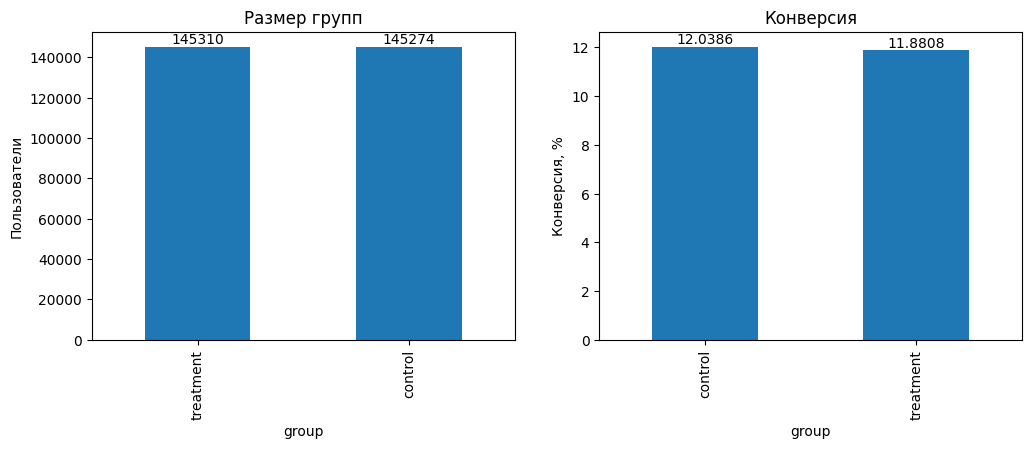

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean['group'].value_counts().plot.bar(ax=axes[0], title='Размер групп', ylabel='Пользователи')
(df_clean.groupby('group')['converted'].mean() * 100).plot.bar(ax=axes[1], title='Конверсия', ylabel='Конверсия, %')

axes[0].bar_label(axes[0].containers[0])
axes[1].bar_label(axes[1].containers[0])

plt.show()

**группы практически одинакового размера - супер, все корректно.**

по конверсии разница между control и treatment небольшая.
насколько она значима статистически: проверим позже с помощью теста...

Построим еще раз кросс-таблицу чтобы проверить, что все хорошо после очистки.

In [64]:
pd.crosstab(df_clean['group'], df_clean['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145310,0


### Базовый EDA завершен.
**control видит только old_page, treatment -- только new_page.**

группы одинакового размера. идем дальше!!1

## Оцениваем по времени

### Рассмотрим трафик по дням

In [65]:
import plotly.express as px
# захотелось плотли

In [66]:
df_clean['date'] = df_clean['timestamp'].dt.date

daily = df_clean.groupby('date', as_index=False)['user_id'].count()

px.bar(daily, x='date', y='user_id', title='Трафик по дням', labels={'date': 'Дата', 'user_id': 'Количество визитов'}).show()

/tmp/ipykernel_5994/2990376165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = df_clean['timestamp'].dt.date


13к визитов в день, трафик равномерный. первый и последний день неполные

теперь рассмотриим по группам

In [67]:
daily_group = df_clean.groupby(['date', 'group'], as_index=False)['user_id'].count()
px.line(daily_group, x='date', y='user_id', color='group', title='Трафик по группам по дням').show()

control и treatment достаточно корректно распределены. все ок!

думаю стоит рассмотреть и конверсию по дням

In [68]:
daily_cr = df_clean.groupby(['date', 'group'], as_index=False)['converted'].mean()
px.line(daily_cr, x='date', y='converted', color='group', title='Конверсия по дням').show()

особого тренда нет. конверсия обеих групп держится в районе 11–12.5%.

рассмотрим по часам

In [69]:
df_clean['hour'] = df_clean['timestamp'].dt.hour
hourly = df_clean.groupby('hour', as_index=False)['user_id'].count()
px.bar(hourly, x='hour', y='user_id', title='Активность по часам').show()

/tmp/ipykernel_5994/3977321909.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



распределение крайне равномерное - разница между часами очень мала. у реального трафика по идее должны быть пики утром и вечером.

**я считаю, что данные синтетические**

Предположим, что user_id генерируется последовательно по времени регистрации пользователя на платформе. Посмотрим как они распределены в разных группах.

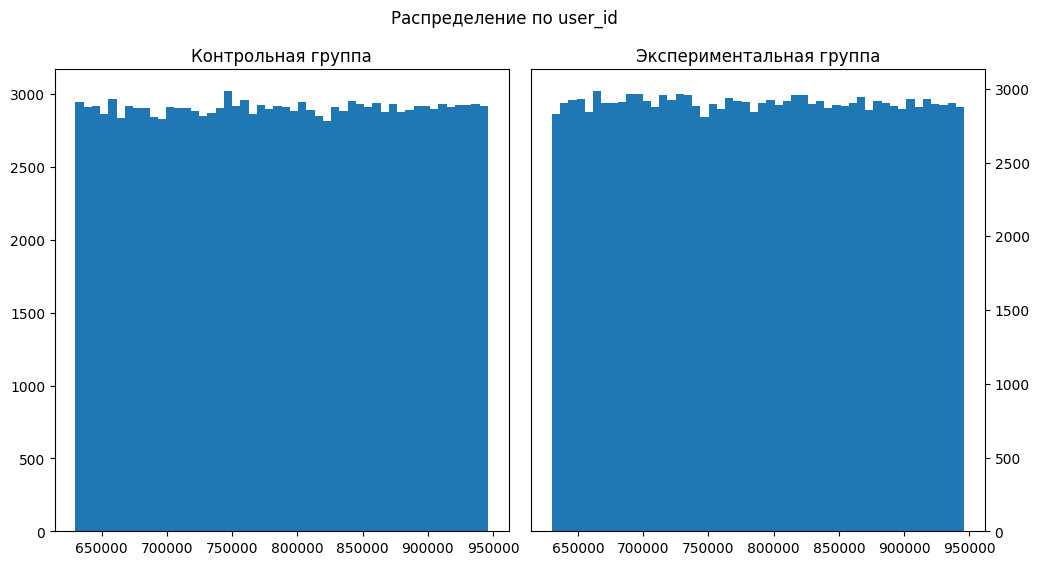

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(df_clean.loc[df_clean['group'] == 'control','user_id'], bins = 50)
ax[1].hist(df_clean.loc[df_clean['group'] == 'treatment', 'user_id'], bins = 50)
ax[0].set_title('Контрольная группа')
ax[1].set_title('Экспериментальная группа')
ax[1].yaxis.set_ticks_position('right')
plt.subplots_adjust(wspace = 0.05)
fig.suptitle("Распределение по user_id")
plt.show()

ID пользователей распределены равномерно как нутри каждой из групп, так и между разными группами

In [71]:
hourly_cr = df_clean.groupby(['hour', 'group'], as_index=False)['converted'].mean()
px.line(hourly_cr, x='hour', y='converted', color='group', title='Конверсия по часам').show()

Посмотрим кумулятивную конверсию за период. Как она изменяется, если с течением времени значения конверсии стабилизировались и перестали резко изменяться и главное пересекаться между группами, это будет означать, что оно стабилизировалось и выборка достаточная

In [72]:
cumulative_temp_day = df_clean.groupby(['date', 'group']).agg(users=('user_id', 'count'),converted=('converted', 'sum')).reset_index()
cumulative_temp_day = cumulative_temp_day.sort_values(by=['group', 'date'])
cumulative_temp_day

,date,group,users,converted
0,2025-01-02,control,2859,359
2,2025-01-03,control,6590,750
4,2025-01-04,control,6578,802
6,2025-01-05,control,6427,792
8,2025-01-06,control,6606,762
10,2025-01-07,control,6604,799
12,2025-01-08,control,6687,795
14,2025-01-09,control,6628,793
16,2025-01-10,control,6654,751
18,2025-01-11,control,6688,795


In [73]:
cumulative_temp_day['cumulative_users'] = cumulative_temp_day.groupby('group')['users'].cumsum()
cumulative_temp_day['cumulative_converted'] = cumulative_temp_day.groupby('group')['converted'].cumsum()
cumulative_temp_day['cumulative_conversion'] = cumulative_temp_day['cumulative_converted'] / cumulative_temp_day['cumulative_users']
cumulative_temp_day

,date,group,users,converted,cumulative_users,cumulative_converted,cumulative_conversion
0,2025-01-02,control,2859,359,2859,359,0.125568
2,2025-01-03,control,6590,750,9449,1109,0.117367
4,2025-01-04,control,6578,802,16027,1911,0.119236
6,2025-01-05,control,6427,792,22454,2703,0.120379
8,2025-01-06,control,6606,762,29060,3465,0.119236
10,2025-01-07,control,6604,799,35664,4264,0.119560
12,2025-01-08,control,6687,795,42351,5059,0.119454
14,2025-01-09,control,6628,793,48979,5852,0.119480
16,2025-01-10,control,6654,751,55633,6603,0.118689
18,2025-01-11,control,6688,795,62321,7398,0.118708


In [74]:
px.line(cumulative_temp_day, x = 'date', y = 'cumulative_conversion', color = 'group', title = 'График кумулятивной конверсии')

Можно увидеть, что приблизительно последнюю неделю теста, конверсия постепенно выходит на плато, графики не скачут, значит, она стабилизировалась

## Корректность теста

Вспомним контекст: мы хотим ответить на вопрос лучше ли новый лендинг старого?
Чтобы этот вопрос был честным, нам нужно убедиться, что тест был проведён правильно.

#### Что я собираюсь проверить?
1. **Однородность групп** — были ли группы одинаковыми до теста? У нас нет соцдем покзаателей пользователей, поэтому смотрим на то что есть — одинаково ли распределены группы по времени суток, по дням недели.
2. **Временные метки** — мы уже смотрели на трафик по дням. Можно посомтреть по дням недели. Вдруг treatment попал на выходные, а контрольная — на будни? Это оч важно, потому что поведение людей в пятницу вечером и в среду утром сильно отличается.

In [75]:
df_clean['group'].value_counts()

,count
group,
treatment,145310
control,145274


Группы почти одинаковые — разница в 37 человек из 290к. Гуд, идем дальше

In [76]:
df_clean['weekday'] = df_clean['timestamp'].dt.day_name()
weekday_group = df_clean.groupby(['weekday', 'group'], as_index=False)['user_id'].count()
px.bar(weekday_group, x='weekday', y='user_id', color='group', barmode='group', title='Трафик по дням недели').show()

/tmp/ipykernel_5994/982930401.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Обе группы получали пользователей равномерно в каждый день недели.
Перекоса нет: тест однороден по времени.

In [77]:
cr_weekday = df_clean.groupby(['weekday', 'group'], as_index=False)['converted'].mean()
px.bar(cr_weekday, x='weekday', y='converted', color='group', barmode='group', title='Конверсия по дням недели').show()

КОнверсия по дням недели у обеих групп примерно одинаковая и нигде особо не расходится. Нет ни одного дня, где treatment стабильно выигрывает или проигрывает.

## Выбор метрик и гипотезы

### Выбор метрики

В качестве метрики можно выбрать **Конверсию (или Conversion Rate (CR))** — долю пользователей, совершивших целевое действие (регистрацию на курс).

**Почему конверсия:**
1. Напрямую отражает цель теста — влияет ли новый лендинг на целевео действие
2. Легко понятен бизнесу
3. `converted` — бинарная переменная, что позволяет применить стандартные стат. тесты

In [78]:
cr_control = df_clean[df_clean['group'] == 'control']['converted'].mean()
cr_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].mean()
diff = cr_treatment - cr_control

In [79]:
print(f'конверсия контрольной группы: {cr_control} ({cr_control*100}%)')
print(f'конверсия тестовой группы: {cr_treatment} ({cr_treatment*100}%)')
print(f'разница в конверсии: {diff} ({diff*100} п.п.)')

конверсия контрольной группы: 0.1203863045004612 (12.03863045004612%)
конверсия тестовой группы: 0.11880806551510564 (11.880806551510565%)
разница в конверсии: -0.0015782389853555567 (-0.15782389853555567 п.п.)


### Гипотезы

**H0 (нулевая):** Конверсия контрольной и экспериментальной групп одинакова.
Новый лендинг не влияет на вероятность регистрации.

H0: CR_control = CR_treatment


---
**H1 (Альтернативная гипотеза):** конверсия в группах отличается.
То есть новый лендинг всё-таки как-то влияет на регистрацию.

H1: CR_control != CR_treatment

Я использую двустороннюю гипотезу, потому что заранее неизвестно, станет конверсия выше или ниже. Проверяем просто сам факт отличия.




**Важное уточнение**, эти параметры определяются на уровне дизайна теста, так как помогают определить минимальную выборку, необходимую для проведения теста. В нашем же случае мы занимаемся скорее подбором их для интерпретации полученных результатов, при этом так как у нас уже есть значение выборки, то мы не можем сами задать все три параметра(альфа, MDE и мощность), мы задаем лишь два из них, а третий автоматически будет определяться. Мы пришли к решению, что лучше всего зафиксировать уровень значимости и MDE, и потом уже смотреть какая мощность получится.


### Уровень значимости и практическая значимость

**Уровень значимости a = 0.05** — будет норм, и так принято в целом в больших командах.
Мы допускаем 5% вероятность ошибочно отвергнуть нулевую гипотезу (найти эффект там, где его нет).

**MDE (минимальный детектируемый эффект)** — это минимальная разница в конверсии, которая вообще интересна бизнесу. Важно понимать, что статистическая значимость и практическая значимость — это разные вещи.

Например, тест может показать разницу в 0.01% — и это будет статистически значимо, если выборка большая. Но бизнесу такой результат неинтересен, потому что внедрение нового лендинга стоит денег и времени. У нас базовый cr около 12%, поэтому разумный порог mde -- 1 п.п.
__Если новый лендинг даёт меньше — забиваем на это.__

Посмотрим, как изменится выручка компании при росте конверсии на 1%:

290к уникальных пользователей за 22 дня (для простоты отбросим возможную сезонность, тренд и тд) - это 13,18к пользователей в день или 395,5к пользователей в месяц, 1% от этого количества это соотвественно 3,95к зарегистрированных на курс пользователей/проданных курсов. Предположим, что это небольшой курс и он стоит 10к рублей, в таком случае, месячная выручка компании **повысится на 39,5 млн рублей**

***Мощность***
Обычно мощность определяют перед проведением эксперимента, так как это параметр определяемый целью эксперимента и помогающий рассчитать минимально необходимую выборку. В нашем же случае мы имеем уже готовый эксперимент, так что ради интереса, посмотрим, какая мощность теста у нас получится, для заданной выборки, MDE и уровня значимости. Формулу взял отсюда: https://webask.io/glossary/mde .Мощность ~ 100%. Это говорит о том, что если статистически значимое изменение есть, то мы 100% его задектим. Такие пироги!

# ИТОГ EDA

- После очистки в датасете осталось 290585 строк.
- Тест проходил с 2 по 24 января 2025 года, то есть примерно 22 дня.
- Группы получились почти одинаковыми по размеру: около 145к пользователей в каждой. Это супер, так как разделение пользователей на контрольную и экспериментальную группы выглядит корректным.
- **Средняя конверсия в регистрацию составила примерно 12%.**
- В контрольной группе конверсия была около 12.04%, а в экспериментальной — около 11.89%. То есть НАВЕРНОЕ новый лендинг показывает результат чуть хуже старого, но пока **нельзя** делать окончательный вывод без стат проверки.
- Данные скорее всего синтетические — аномально равномерное распределение по часам


In [80]:
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

Проведу синтетический АА тест на 1000 случайных разбиевний контрольной группы. Цель эксперимента - проверить нормально ли собирались данные. Как интерпретировать результат эксперимента: если p-value будет распределено равномерно, тогда какую альфу мы зададим, такую долю ложноположительных результатов (ошибка первого рода, вы беременны, а там вообще ноу ченс быть беременным), если это будет так, то значит, что с выборкой и тем как собирает данные платформа все нормуль. (АА-тест не должен проводиться после АБ-теста, тк только после проведения АА теста, принимают решение о проведении АБ-теста, вот такие пироги, но почему бы не сделать его, раз мы учимся)

Будем использовать z-test, как и далее, так как выборка огромная

In [81]:
control_converted = df_clean.loc[df_clean['group'] == 'control','converted']
control_converted.describe()

,converted
count,145274
unique,2
top,False
freq,127785


In [82]:
n= 1000
p_value = []
for i in range(n):
    control_converted = control_converted.sample(frac = 1, random_state = i)
    first = control_converted.iloc[:(len(control_converted)//2)]
    second = control_converted.iloc[(len(control_converted)//2):]
    conversions = [first.sum(), second.sum()]
    visits = [first.count(), second.count()]
    z_stat, p_val = proportions_ztest(conversions, visits)
    p_value.append(p_val)
p_value = np.array(p_value)
fpr = np.mean(p_value < 0.05)
print(f"Доля ложноположительных результатов: {fpr * 100:.2f}%")


Доля ложноположительных результатов: 5.20%


Все балдежно, доля p-value отсеченная альфой приблизительно равна 5%, значит, выборка нормальная дальше проведем аб-тестик и дополнительно еще бутстрап-анализ.

**Почему z-тест:** у нас бинарная метрика (0/1), две независимые группы, и очень большая выборка (≈145к в каждой).

Z-тест — самый адекватный выбор именно для подобных задачек.

In [83]:
# делим данные на две группы
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

# считаем количество пользователей
n_control = len(control)
n_treatment = len(treatment)

# считаем количество регистраций
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

# считаем конверсию
cr_control = conv_control / n_control
cr_treatment = conv_treatment / n_treatment

In [84]:
print(f'CR control: {cr_control} ({cr_control*100}%)')
print(f'CR treatment: {cr_treatment} ({cr_treatment*100}%)')
print(f'Разница: {cr_treatment - cr_control} ({(cr_treatment - cr_control)*100} п.п.)')

CR control: 0.1203863045004612 (12.03863045004612%)
CR treatment: 0.11880806551510564 (11.880806551510565%)
Разница: -0.0015782389853555567 (-0.15782389853555567 п.п.)


In [85]:
# соответственно сам z-тест
stat, p_value = proportions_ztest(
    [conv_treatment, conv_control],
    [n_treatment, n_control]
)

print('p-value:', round(p_value, 4))

p-value: 0.1899


Бутстрап-анализ, основывался на этом https://habr.com/ru/companies/X5Tech/articles/679842/. Если мы до этого проверяли гипотезу с помощью z-test, то сейчас попробуем через бутстрап и доверительные интервалы. Как будем проверять различие: бутстрап построит 1000 случайных выборок на основе распределений полученного в ходе опыта, посчитаем разницу в конверсиях. Таким образом мы получим 1000 разниц, затем построим 95% доверительный интервал, если 0 будет лежать в этих границах, то отвергаем альтернативную гипотезу

In [86]:
control_converted = df_clean.loc[df_clean['group'] == 'control','converted'].to_numpy()
treatment_converted = df_clean.loc[df_clean['group'] == 'treatment','converted'].to_numpy()
control_converted

array([False, False,  True, ..., False, False, False])

In [87]:
np.random.seed(67)
n = 1000
diff = []
for i in range(n):
    b_control = np.random.choice(control_converted, size=len(control_converted), replace=True)
    b_treatment = np.random.choice(treatment_converted, size=len(treatment_converted), replace=True)
    bcc = np.mean(b_control) * 100
    btc = np.mean(b_treatment) * 100
    diff.append(btc - bcc)
diff = np.array(diff)
diff

array([-1.26838570e-01, -1.13789680e-01, -1.98424019e-01, -1.32967563e-02,
       -8.14199687e-02, -1.45421581e-01, -2.21850239e-01, -6.28591272e-02,
       -9.10547136e-02, -2.04619550e-01, -1.26179520e-02, -2.79654616e-01,
       -2.77585971e-01,  2.59769638e-02, -6.42227047e-02, -1.68861615e-01,
       -4.28833766e-02, -3.38157749e-01, -4.49423005e-02, -9.17352233e-02,
       -3.09235267e-01, -1.39244980e-01, -2.14941285e-01, -1.88798824e-01,
       -2.14951006e-01,  5.07125306e-02, -3.94477438e-02, -1.48176704e-01,
       -8.76165227e-02, -1.01399983e-01, -5.59450569e-02, -1.50960478e-01,
        4.52205320e-02, -9.17225751e-03, -4.21820614e-02, -1.61310181e-01,
       -2.25271547e-01, -1.84676713e-01, -2.92731303e-01, -3.41587584e-01,
       -3.31980125e-01, -1.40590992e-01, -2.58295164e-01,  3.48837897e-02,
       -5.87025674e-02, -2.46603371e-01, -7.93458669e-02, -6.39618614e-01,
       -3.93215530e-01, -6.14426832e-02, -3.37477751e-01, -7.59402487e-02,
       -1.15156839e-01, -

In [88]:
ql = np.percentile(diff, 2.5)
qr = np.percentile(diff, 97.5)
exp_diff = (cr_treatment - cr_control)*100
bp_value = np.mean(np.abs(diff) >= np.abs(exp_diff))
print(f"Наблюдаемая разница конверсий (Treatment - Control): {exp_diff:.3f}%")
print(f"95% Доверительный интервал: [{ql:.3f}%, {qr:.3f}%]")
print(f"p-value из бутстрап-анализа: {bp_value:.4f}")


Наблюдаемая разница конверсий (Treatment - Control): -0.158%
95% Доверительный интервал: [-0.388%, 0.084%]
p-value из бутстрап-анализа: 0.4960


In [89]:
from statsmodels.stats.proportion import proportion_confint

In [90]:
ci_c = proportion_confint(conv_control, n_control, alpha=0.05, method='normal')
ci_t = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method='normal')

print(f'95% доверительный интервал для контрольной группы: {ci_c}')
print(f'95% доверительный интервал для тестовой группы: {ci_t}')

95% доверительный интервал для контрольной группы: (0.11871294722381814, 0.12205966177710426)
95% доверительный интервал для тестовой группы: (0.11714442856134422, 0.12047170246886707)


### ВЫВОД ПО РЕЗУЛЬТАТАМ
**z-test**
**p-value=0.1899 >>> а=0.05**
**bootstrap**
**0 Находится внутри 95% доверительного интервала, как разница конверсий из эксперимента**

Значит мы не отвергаем H0.
Статистически значимой разницы между группами нет.

Новый лендинг **не улучшил конверсию.**
Доверительные интервалы это подтверждают -- они сильно перекрываются:

Control: (11.87%, 12.21%) Treatment: (11.71%, 12.05%)

Если бы эффект был реальным — интервалы бы не пересекались

## **Новый лендинг внедрять не стоит.**

### Дополнительные выводы
**Данные скорее всего синтетические (клики равномерно распределены по времени в рамках дня, даже учитывая возможность проводить эксперимент с пользователями с разных концов света - это очень маловероятно)**

**Рекомендуем проводить дизайн АВ-теста перед запуском, так можно сильно сократить расходы на тест. В данном случае выборка получилась огромной и явно затраты на проведение эксперимента могли быть меньше**

Предположим, что MDE и показатель значимости остались такими же, а мощность мы выставили по стандарту на 80%. В таком случае было бы достаточно общей выборки примерно 33020 уникальных показов, и в каждой группе было бы 16510 измерений.